<img src="udc1.png" alt="UDC"/>

# Notebook pour la classification d'images(déchets) avec JEPA. 

In [1]:
import outils
import numpy as np
import matplotlib.pyplot as plt
import os 
import pandas as pd
import math
import random

In [37]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)


In [2]:
df = outils.Load_data.load_object("dataset2.zip")

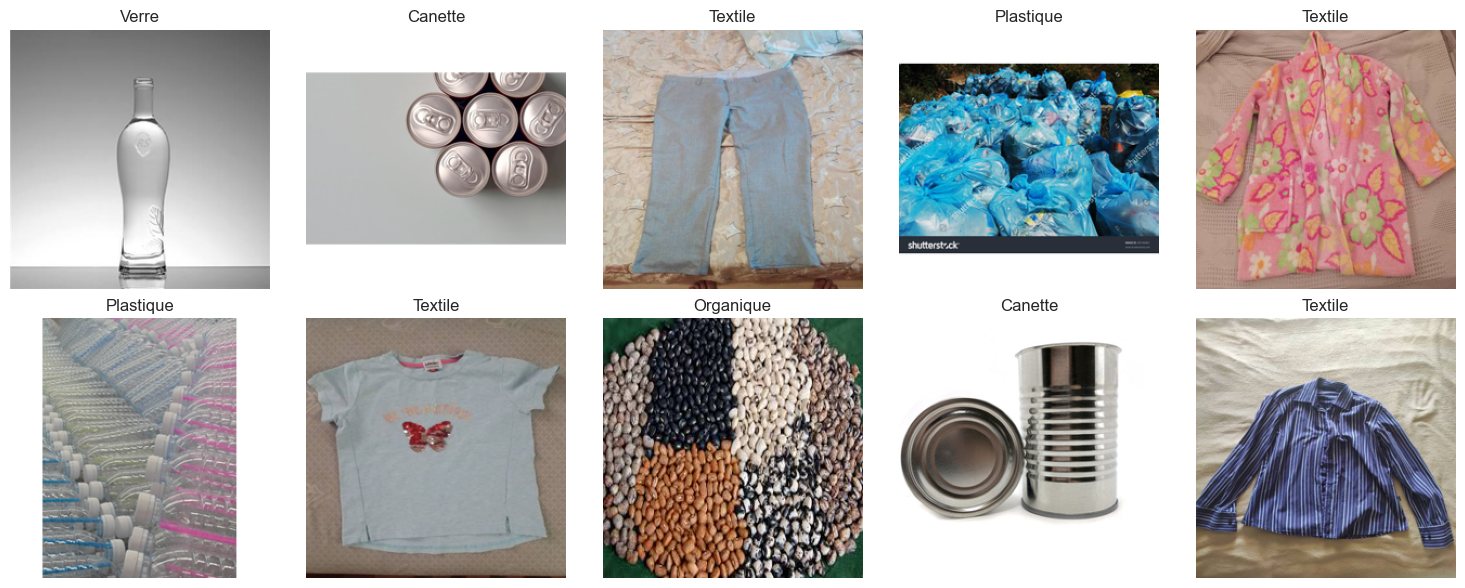

In [3]:
df.plot(n_samples=10)

In [4]:
df.reshape(target_shape=(64, 64, 3))

Reshape en batch: 100%|██████████| 380/380 [00:18<00:00, 20.65it/s]


In [5]:
df.encodage()

Encodage effectué. Mapping: {'Canette': 0, 'Organique': 1, 'Plastique': 2, 'Textile': 3, 'Verre': 4}


In [6]:
(X_train, y_train), (X_test, y_test) = df.create_data(test_size=0.2)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import LearningRateScheduler,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model, Input
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Dropout, Add, BatchNormalization, Input, Flatten
from keras.saving import register_keras_serializable

In [9]:
# Dimensions
IMG_HEIGHT = 64
IMG_WIDTH = 64
IMG_CHANNELS = 3
EMBED_DIM = 128           # Dimension de l'espace latent
NUM_CLASSES = 5
BATCH_SIZE = 64
EPOCHS_JEPA = 100          # Pré-entraînement auto-supervisé
EPOCHS_CLASS = 50         # Classification supervisée
EMA_DECAY = 0.99          # Pour l'encodeur cible
PATCH_SIZE = 8

In [10]:
@register_keras_serializable()
class PatchExtractor(layers.Layer):
    """Extrait des patches et les reshape pour le transformer."""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        # images: (batch, H, W, C)
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        batch_size = tf.shape(images)[0]
        num_patches = (tf.shape(images)[1] // self.patch_size) ** 2
        patch_dim = patches.shape[-1]  # channels * patch_size * patch_size
        patches = tf.reshape(patches, (batch_size, num_patches, patch_dim))
        return patches



In [42]:
@register_keras_serializable()
def build_encoder(embed_dim=128, input_shape=(64, 64, 3), patch_size=8):
    """Encodeur simple compatible avec IJEPADataGenerator."""
    num_patches = (input_shape[0] // patch_size) ** 2
    inputs = layers.Input(shape=input_shape)

    # CNN
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Extraire les patches via notre couche
    patches = PatchExtractor(patch_size)(x)

    # Dense pour embed_dim
    embeddings = layers.Dense(embed_dim, activation='relu')(patches)

    return Model(inputs, embeddings, name='encoder')

In [12]:
EMBED_DIM = 128  
NUM_CLASSES = 5  


@register_keras_serializable()
def build_predictor(embed_dim=EMBED_DIM, hidden_dim=256):
    """
    Predictor simple mais puissant pour IJEPA.
    - Prend en entrée les embeddings de patchs (batch, num_patches, embed_dim)
    - Retourne les embeddings prédits pour les patches masqués
    """
    inputs = tf.keras.Input(shape=(None, embed_dim), name='predictor_input')
    
    # Bloc Transformer-like simple pour prédiction
    x = layers.LayerNormalization()(inputs)
    x = layers.Dense(hidden_dim, activation='relu')(x)
    x = layers.Dense(embed_dim)(x)  # sortie embed_dim par patch
    
    return Model(inputs, x, name='predictor')


In [13]:
@register_keras_serializable()
def build_classifier(embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                     hidden_dims=[128, 64], dropout_rate=0.2):
   
    inputs = tf.keras.Input(shape=(embed_dim,), name='classifier_input')
    x = inputs
    
    for i, hidden_dim in enumerate(hidden_dims):
        x = layers.Dense(hidden_dim, kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout_rate)(x)
    
    outputs = layers.Dense(num_classes, name='logits')(x)
    
    return Model(inputs, outputs, name='classifier')

In [14]:
class JEPAMaskingConfig:
    """
    Configuration du masquage selon l'article I-JEPA.
    
    Référence: Section 3 - Method, et Appendix C
    """
    
    def __init__(self, img_size=224, patch_size=16):
        """
        Args:
            img_size: taille de l'image en pixels (H=W)
            patch_size: taille de chaque patch en pixels
        """
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.grid_size = img_size // patch_size
        
        # Paramètres des cibles (target blocks) - Section 3
        self.target_scale_min = 0.15      # Échelle min des blocs cibles
        self.target_scale_max = 0.20      # Échelle max des blocs cibles
        self.target_aspect_min = 0.75     # Ratio d'aspect min
        self.target_aspect_max = 1.5      # Ratio d'aspect max
        self.num_targets = 4              # Nombre de blocs cibles (M=4)
        
        # Paramètres du contexte (context block) - Section 3
        self.context_scale_min = 0.85     # Échelle min du bloc contexte
        self.context_scale_max = 1.0      # Échelle max du bloc contexte
        self.context_aspect = 1.0         # Ratio d'aspect du contexte (carré)


In [15]:

class JEPAMaskGenerator:
    """
    Générateur de masques pour I-JEPA.
    Produit les indices des patches pour le contexte et les cibles.
    
    Référence: Section 3 - Method, "Masking strategy"
    """
    
    def __init__(self, config):
        self.config = config
        
    def _random_block(self, scale_min, scale_max, aspect_min=None, aspect_max=None, aspect_fixed=None):
       
        grid = self.config.grid_size
        
        # Échelle en nombre de patches
        scale = random.uniform(scale_min, scale_max)
        area = scale * scale * grid * grid  # surface en nombre de patches
        
        # Ratio d'aspect
        if aspect_fixed is not None:
            aspect = aspect_fixed
        else:
            aspect = random.uniform(aspect_min, aspect_max)
        
        # Dimensions en patches
        w_patches = int(round(math.sqrt(area * aspect)))
        h_patches = int(round(math.sqrt(area / aspect)))
        
        # Ajuster pour rester dans les limites
        w_patches = min(w_patches, grid - 1)
        h_patches = min(h_patches, grid - 1)
        
        if w_patches < 1:
            w_patches = 1
        if h_patches < 1:
            h_patches = 1
        
        # Position aléatoire
        x = random.randint(0, grid - w_patches)
        y = random.randint(0, grid - h_patches)
        
        return x, y, w_patches, h_patches
    
    def _block_to_indices(self, x, y, w, h):
        
        grid = self.config.grid_size
        indices = []
        for row in range(y, y + h):
            for col in range(x, x + w):
                idx = row * grid + col
                indices.append(idx)
        return indices
    
    def generate_masks(self, batch_size):
        
        context_masks = []
        target_masks_list = []
        
        for _ in range(batch_size):
            # 1. Générer les blocs cibles (M=4)
            target_blocks = []
            target_blocks_coords = []
            
            for _ in range(self.config.num_targets):
                x, y, w, h = self._random_block(
                    self.config.target_scale_min,
                    self.config.target_scale_max,
                    self.config.target_aspect_min,
                    self.config.target_aspect_max
                )
                target_blocks.append(self._block_to_indices(x, y, w, h))
                target_blocks_coords.append((x, y, w, h))
            
            # 2. Générer le bloc contexte
            ctx_x, ctx_y, ctx_w, ctx_h = self._random_block(
                self.config.context_scale_min,
                self.config.context_scale_max,
                aspect_fixed=self.config.context_aspect
            )
            context_idx = set(self._block_to_indices(ctx_x, ctx_y, ctx_w, ctx_h))
            
            # 3. Supprimer les chevauchements avec les cibles
            #    (comme décrit dans l'article: "remove any overlapping regions from the context block")
            for target_block in target_blocks:
                context_idx = context_idx - set(target_block)
            
            # Sauvegarder
            context_masks.append(list(context_idx))
            target_masks_list.append(target_blocks)
        
        return context_masks, target_masks_list
    
    def visualize_masks(self, image, context_mask, target_masks):
       
        grid = self.config.grid_size
        patch_size = self.config.patch_size
        h, w = image.shape[:2]
        
        # Créer une copie
        vis = image.copy().astype(np.uint8)
        
        # Couleurs pour les cibles (RGB)
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
        
        # Dessiner les cibles
        for i, target_mask in enumerate(target_masks):
            color = colors[i % len(colors)]
            for idx in target_mask:
                row = idx // grid
                col = idx % grid
                y1 = row * patch_size
                x1 = col * patch_size
                y2 = y1 + patch_size
                x2 = x1 + patch_size
                # Mélanger l'image originale avec la couleur
                vis[y1:y2, x1:x2] = vis[y1:y2, x1:x2] * 0.4 + np.array(color) * 0.6
        
        # Dessiner le contexte (en cyan)
        for idx in context_mask:
            row = idx // grid
            col = idx % grid
            y1 = row * patch_size
            x1 = col * patch_size
            y2 = y1 + patch_size
            x2 = x1 + patch_size
            vis[y1:y2, x1:x2] = vis[y1:y2, x1:x2] * 0.4 + np.array([0, 255, 255]) * 0.6
        
        return vis


In [43]:
class IJEPADataGenerator(tf.keras.utils.Sequence):
    """
    Générateur de données pour I-JEPA avec masquage.
    Retourne ((images_masquees, target_data), labels)
    """
    
    def __init__(self, images, labels=None, batch_size=32, img_size=64, patch_size=8, shuffle=True):
        self.images = images.astype(np.float32)
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.patch_size = patch_size
        self.shuffle = shuffle
        
        self.config = JEPAMaskingConfig(img_size, patch_size)
        self.mask_generator = JEPAMaskGenerator(self.config)
        
        self.indices = np.arange(len(images))
        if shuffle:
            np.random.shuffle(self.indices)
    
    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))
    
    def _apply_mask_to_image(self, image, context_mask):
        grid = self.config.grid_size
        patch_size = self.config.patch_size
        masked_image = np.zeros_like(image, dtype=np.float32)
        
        for idx in context_mask:
            row = idx // grid
            col = idx % grid
            y1 = row * patch_size
            x1 = col * patch_size
            y2 = y1 + patch_size
            x2 = x1 + patch_size
            masked_image[y1:y2, x1:x2] = image[y1:y2, x1:x2]
        
        return masked_image
    
    def _pad_target_masks(self, target_masks_list):
        """
        Pad les target_masks pour qu'ils aient tous la même taille.
        """
        batch_size = len(target_masks_list)
        if batch_size == 0:
            return np.array([]), np.array([])
        
        num_targets = len(target_masks_list[0])
        
        # ✅ Calcul correct de max_patches
        max_patches = 0
        for masks in target_masks_list:
            for m in masks:
                max_patches = max(max_patches, len(m))
        
        # ✅ Si max_patches est trop petit, au moins 4
        max_patches = max(max_patches, 4)
        
        padded_masks = np.zeros((batch_size, num_targets, max_patches), dtype=np.int32)
        mask_lengths = np.zeros((batch_size, num_targets), dtype=np.int32)
        
        for i, masks in enumerate(target_masks_list):
            for j, m in enumerate(masks):
                length = len(m)
                mask_lengths[i, j] = length
                if length > 0:
                    padded_masks[i, j, :length] = m
        
        return padded_masks, mask_lengths
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images = self.images[batch_indices]
        batch_images = batch_images / 255.0
        
        # Générer les masques
        context_masks, target_masks_list = self.mask_generator.generate_masks(len(batch_images))
        
        # Appliquer les masques
        context_images = []
        for i, img in enumerate(batch_images):
            masked = self._apply_mask_to_image(img, context_masks[i])
            context_images.append(masked)
        context_images = np.array(context_images, dtype=np.float32)
        
        # Pad les target_masks
        padded_target_masks, mask_lengths = self._pad_target_masks(target_masks_list)
        
        # Convertir en tenseurs
        padded_target_masks = tf.constant(padded_target_masks, dtype=tf.int32)
        mask_lengths = tf.constant(mask_lengths, dtype=tf.int32)
        target_data = (padded_target_masks, mask_lengths)
        
        if self.labels is not None:
            batch_labels = self.labels[batch_indices]
            batch_labels = tf.constant(batch_labels, dtype=tf.int32)
            return (context_images, target_data), batch_labels
        else:
            dummy_labels = tf.zeros(len(batch_indices), dtype=tf.int32)
            return (context_images, target_data), dummy_labels
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def visualize_batch(self, batch_idx=0, save_path=None):
        
        
        # Récupérer le batch
        (context_images, target_data), labels = self[batch_idx]
        padded_target_masks, mask_lengths = target_data
        
        # Récupérer les images originales
        batch_indices = self.indices[batch_idx * self.batch_size:(batch_idx + 1) * self.batch_size]
        original_images = self.images[batch_indices].astype(np.uint8)
        
        # ✅ Vérifier le type et convertir si nécessaire
        if hasattr(context_images, 'numpy'):
            context_images = context_images.numpy()
        if hasattr(padded_target_masks, 'numpy'):
            padded_target_masks = padded_target_masks.numpy()
        if hasattr(mask_lengths, 'numpy'):
            mask_lengths = mask_lengths.numpy()
        
        # Reconstruire les target_masks
        target_masks_list = []
        for i in range(padded_target_masks.shape[0]):
            masks = []
            for j in range(padded_target_masks.shape[1]):
                length = mask_lengths[i, j] if mask_lengths.ndim > 1 else mask_lengths[j]
                if length > 0:
                    masks.append(padded_target_masks[i, j, :length].tolist())
                else:
                    masks.append([])
            target_masks_list.append(masks)
        
        # Générer les masques de contexte pour la visualisation
        context_masks, _ = self.mask_generator.generate_masks(len(original_images))
        
        n_images = min(4, len(context_images))
        fig, axes = plt.subplots(n_images, 4, figsize=(10, 2 * n_images))
        
        if n_images == 1:
            axes = axes.reshape(1, -1)
        
        for i in range(n_images):
            # 1. Image originale
            axes[i, 0].imshow(original_images[i])
            axes[i, 0].set_title(f"Originale {i+1}")
            axes[i, 0].axis('off')
            
            # 2. Image masquée (seul le contexte)
            axes[i, 1].imshow(context_images[i])
            axes[i, 1].set_title(f"Contexte masqué")
            axes[i, 1].axis('off')
            
            # 3. Visualisation des cibles
            vis_targets = self.mask_generator.visualize_masks(
                original_images[i],
                [],  # pas de contexte pour cette visualisation
                target_masks_list[i]
            )
            axes[i, 2].imshow(vis_targets)
            axes[i, 2].set_title(f"Cibles (4 blocs)")
            axes[i, 2].axis('off')
            
            # 4. Visualisation complète (contexte + cibles)
            vis_full = self.mask_generator.visualize_masks(
                original_images[i],
                context_masks[i],
                target_masks_list[i]
            )
            axes[i, 3].imshow(vis_full)
            axes[i, 3].set_title(f"Contexte + Cibles")
            axes[i, 3].axis('off')
        
        plt.tight_layout()
            
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure sauvegardée: {save_path}")
        
        plt.show()
        plt.close(fig)

In [44]:
X_train.max()

np.float32(255.0)

In [45]:
train_generator = IJEPADataGenerator(
    X_train, y_train,
    batch_size=16,
    img_size=64,
    patch_size=8,
    shuffle=True
)
test_datagen =  ImageDataGenerator(rescale= 1. / 255)

In [46]:
test_generator  = test_datagen.flow(X_test,y_test,batch_size=16)

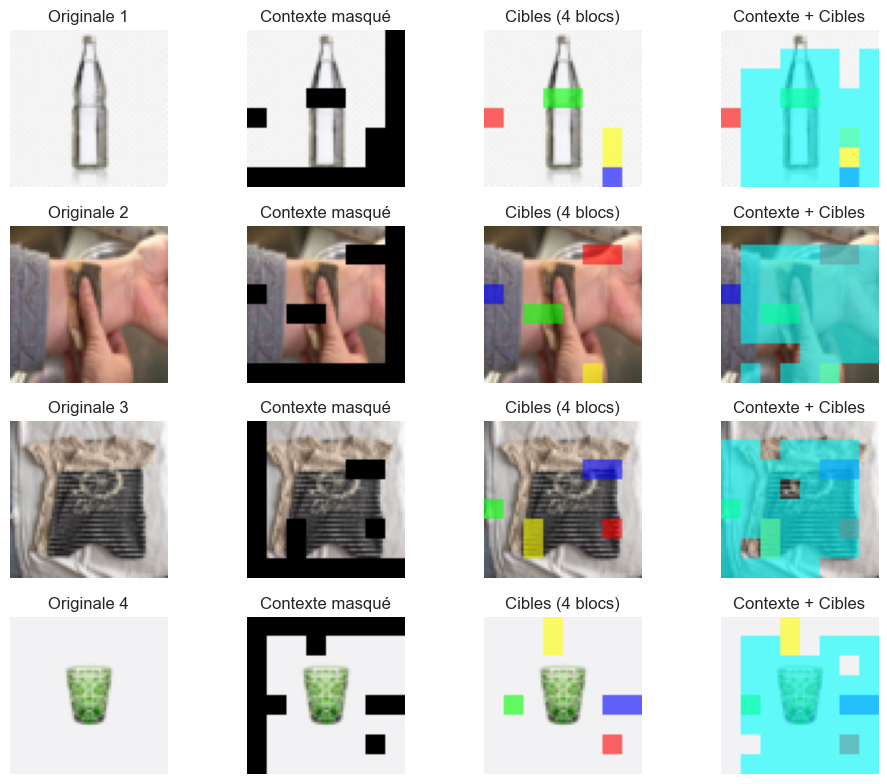

In [47]:
train_generator.visualize_batch(batch_idx=3)

In [48]:
EMBED_DIM = 128
NUM_CLASSES = 5
EMA_DECAY = 0.996
IMG_SIZE = 64
PATCH_SIZE = 8

In [49]:
@register_keras_serializable()
class IJEPAModel(Model):
    """
    Modèle I-JEPA complet.
    """
    
    def __init__(self,
                 embed_dim=EMBED_DIM,
                 num_classes=NUM_CLASSES,
                 num_patches=(IMG_SIZE // PATCH_SIZE) ** 2,
                 lambda_jepa=0.5,
                 ema_decay=EMA_DECAY,
                
                 **kwargs):
        super().__init__(**kwargs)
        
        self.embed_dim = embed_dim
        self.num_classes = num_classes
        self.num_patches = num_patches
        self.lambda_jepa = lambda_jepa
        self.ema_decay = ema_decay
       
        self.encoder = build_encoder(embed_dim)
        self.target_encoder = build_encoder(embed_dim)
        
        self.predictor = build_predictor(embed_dim)
        self.classifier = build_classifier(embed_dim, num_classes)
        
        # Embeddings de position
        self.pos_embedding = self.add_weight(
            name="pos_embedding",
            shape=(1, num_patches, embed_dim),
            initializer="random_normal",
            trainable=True
        )
        
        # Token de masque
        self.mask_token = self.add_weight(
            name="mask_token",
            shape=(1, 1, embed_dim),
            initializer="random_normal",
            trainable=True
        )
        
        # Initialiser l'encodeur cible
        self._init_target_encoder()
        
        # Métriques
        self.loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.cls_loss_tracker = tf.keras.metrics.Mean(name="cls_loss")
        self.jepa_loss_tracker = tf.keras.metrics.Mean(name="jepa_loss")
        self.accuracy_tracker = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    
    def _init_target_encoder(self):
        """Initialise l'encodeur cible avec les poids de l'encodeur source"""
        for w, tw in zip(self.encoder.weights, self.target_encoder.weights):
            tw.assign(w)
        self.target_encoder.trainable = False
    
    def _update_target_encoder(self):
        """Met à jour l'encodeur cible par EMA"""
        for w, tw in zip(self.encoder.weights, self.target_encoder.weights):
            tw.assign(self.ema_decay * tw + (1 - self.ema_decay) * w)
    
    def _get_patch_embeddings(self, encoder, images, training=False):
        """Extrait les embeddings par patch - l'encodeur sort déjà (batch, num_patches, embed_dim)"""
        return encoder(images, training=training)
    
    def compute_jepa_loss(self, images, target_data):
        """
        Calcule la perte JEPA pour les patches cibles.
        target_data = (padded_masks, mask_lengths)
        """
        padded_masks, mask_lengths = target_data

        # Embeddings contexte
        z_context = self._get_patch_embeddings(self.encoder, images, training=True)

        # Embeddings cibles (via target_encoder)
        z_target = self._get_patch_embeddings(self.target_encoder, images, training=False)

        batch_size = tf.shape(z_context)[0]
        num_targets = tf.shape(padded_masks)[1]

        total_loss = tf.constant(0.0, dtype=tf.float32)
        n_valid = tf.constant(0, dtype=tf.float32)

        for b in tf.range(batch_size):
            ctx = z_context[b]        # (num_patches, embed_dim)
            tgt = z_target[b]         # (num_patches, embed_dim)
            masks = padded_masks[b]   # (num_targets, max_patches)
            lengths = mask_lengths[b] # (num_targets,)

            for j in tf.range(num_targets):
                length = lengths[j]

                def valid_case():
                    idx = masks[j, :length]                  # indices valides
                    target_emb = tf.gather(tgt, idx)         # (length, embed_dim)
                    pos = tf.gather(self.pos_embedding[0], idx)  # (length, embed_dim)

                    # ✅ Correction: mask_tokens avec les bonnes dimensions
                    # self.mask_token a shape (1, 1, embed_dim) -> on veut (length, embed_dim)
                    mask_tokens = tf.tile(self.mask_token, [length, 1, 1])  # (length, 1, embed_dim)
                    mask_tokens = tf.squeeze(mask_tokens, axis=1)            # (length, embed_dim)
                    mask_tokens = mask_tokens + pos                          # (length, embed_dim)

                    ctx_mean = tf.reduce_mean(ctx, axis=0, keepdims=True)    # (1, embed_dim)
                    ctx_mean = tf.tile(ctx_mean, [length, 1])                # (length, embed_dim)

                    # Entrée du prédicteur: (1, length, embed_dim)
                    pred_input = tf.expand_dims(ctx_mean + mask_tokens, axis=0)

                    # Prédiction
                    pred = self.predictor(pred_input, training=True)  # (1, length, embed_dim)
                    pred = tf.squeeze(pred, axis=0)                   # (length, embed_dim)
                    
                    return tf.reduce_mean(tf.square(pred - target_emb))

                def zero_case():
                    return tf.constant(0.0, dtype=tf.float32)

                loss = tf.cond(length > 0, valid_case, zero_case)
                total_loss += loss
                n_valid += tf.cast(length > 0, tf.float32)

        return total_loss / tf.maximum(n_valid, 1.0)
    
    def call(self, inputs, training=False):
        """
        Forward pass.
        inputs = (images, target_data)
        """
        images, target_data = inputs
        
        # Encodage du contexte
        z_context = self._get_patch_embeddings(self.encoder, images, training=training)
        
        # Classification (moyenne des embeddings contexte)
        z_global = tf.reduce_mean(z_context, axis=1)
        logits = self.classifier(z_global, training=training)
        
        # Perte JEPA
        jepa_loss = None
        if training and target_data is not None:
            # Vérifier que target_data est utilisable
            if isinstance(target_data, (tuple, list)) and len(target_data) == 2:
                if target_data[0] is not None:
                    jepa_loss = self.compute_jepa_loss(images, target_data)
        
        return logits, jepa_loss
    
    def train_step(self, data):
        """Étape d'entraînement"""
        (images, target_data), labels = data
        
        with tf.GradientTape() as tape:
            logits, jepa_loss = self((images, target_data), training=True)
            
            # Perte de classification
            cls_loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
            )
            
            # Perte totale
            if jepa_loss is not None:
                total_loss = cls_loss + self.lambda_jepa * jepa_loss
            else:
                total_loss = cls_loss
        
        # Rétropropagation
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        
        # Mettre à jour l'encodeur cible (EMA)
        self._update_target_encoder()
        
        # Métriques
        self.loss_tracker.update_state(total_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        if jepa_loss is not None:
            self.jepa_loss_tracker.update_state(jepa_loss)
        self.accuracy_tracker.update_state(labels, logits)
        
        return {
            "total_loss": self.loss_tracker.result(),
            "cls_loss": self.cls_loss_tracker.result(),
            "jepa_loss": self.jepa_loss_tracker.result(),
            "accuracy": self.accuracy_tracker.result()
        }
    
    def test_step(self, data):
    
        """Étape de validation - accepte à la fois les données avec et sans masques"""
        
        # ✅ Gérer les différents formats
        if isinstance(data, (list, tuple)):
            if len(data) == 2:
                # Cas 1: (images, labels) - validation standard
                # Cas 2: ((images, target_data), labels) - avec masques
                if isinstance(data[0], tuple) and len(data[0]) == 2:
                    # Format avec masques: ((images, target_data), labels)
                    (images, target_data), labels = data
                else:
                    # Format sans masques: (images, labels)
                    images, labels = data
                    target_data = None
            elif len(data) == 3:
                # Format: (images, target_data, labels)
                images, target_data, labels = data
            else:
                images = data[0]
                target_data = None
                labels = data[1] if len(data) > 1 else None
        else:
            images = data
            target_data = None
            labels = None
        
        # Forward pass (target_data=None pour les données sans masques)
        logits, jepa_loss = self((images, target_data), training=False)
        
        cls_loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        )
        
        total_loss = cls_loss
        if jepa_loss is not None:
            total_loss = cls_loss + self.lambda_jepa * jepa_loss
            self.jepa_loss_tracker.update_state(jepa_loss)
        
        self.loss_tracker.update_state(total_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.accuracy_tracker.update_state(labels, logits)
        
        return {
            "total_loss": self.loss_tracker.result(),
            "cls_loss": self.cls_loss_tracker.result(),
            "jepa_loss": self.jepa_loss_tracker.result(),
            "accuracy": self.accuracy_tracker.result()
        }
    
    @property
    def metrics(self):
        return [self.loss_tracker, self.cls_loss_tracker, self.jepa_loss_tracker, self.accuracy_tracker]
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_classes": self.num_classes,
            "num_patches": self.num_patches,
            "lambda_jepa": self.lambda_jepa,
            "ema_decay": self.ema_decay,
           
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [50]:
model = IJEPAModel()

In [51]:
model.encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_extractor_6               │ (None, 64, 8192)       │             0 │
│ (PatchExtractor)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64, 128)        │     1,048,704 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,848 (4.36 MB)

 Trainable params: 1,142,400 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [52]:
model.predictor.summary()


Model: "predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ predictor_input (InputLayer)    │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, None, 128)      │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, None, 256)      │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, None, 128)      │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,176 (258.50 KB)

 Trainable params: 66,176 (258.50 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.classifier.summary()

Model: "classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier_input (InputLayer)   │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,861 (101.02 KB)

 Trainable params: 25,477 (99.52 KB)

 Non-trainable params: 384 (1.50 KB)

In [54]:
def load_model(filepath):
   
    custom_objects = {
        'JEPA_Model': IJEPAModel,
        'build_encoder': build_encoder,
        'build_predictor': build_predictor,
        'build_classifier': build_classifier
    }
    
   
    model = tf.keras.models.load_model(
        filepath,
        custom_objects=custom_objects,
        compile=False
    )
    
    return model


In [55]:
def format_time(seconds):
    """Convertit un temps en secondes en format jours:heures:minutes:secondes"""
    days = int(seconds // 86400)
    hours = int((seconds % 86400) // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    
    if days > 0:
        return f"{days}j {hours}h {minutes}m {secs}s"
    elif hours > 0:
        return f"{hours}h {minutes}m {secs}s"
    elif minutes > 0:
        return f"{minutes}m {secs}s"
    else:
        return f"{secs}s"

In [56]:
import time

initial_learning_rate = 1e-5

# Callbacks avec modes explicites
param_surv_app1 = ModelCheckpoint(
    "model_jepa_cls_3.keras",
    monitor="val_accuracy", 
    verbose=1,
    save_best_only=True,
    mode='max'
)

param_surv_app2 = EarlyStopping(
    monitor='val_total_loss', 
    patience=30,
    verbose=1,
    restore_best_weights=True,
    mode='min'
)

param_surv_app3 = ReduceLROnPlateau(
    monitor='val_total_loss', 
    factor=0.1,
    patience=20,
    verbose=1,
    mode='min'
)

# Compilation
model.compile(optimizer=RMSprop(learning_rate=initial_learning_rate))

# Entraînement
start_time = time.time()

historique = model.fit(
    train_generator,
    epochs=200,
    validation_data=test_generator,
    callbacks=[param_surv_app1, param_surv_app2, param_surv_app3]
)

end_time = time.time()
elapsed = end_time - start_time
print(f"Temps d'entraînement : {format_time(elapsed)}")


Epoch 1/200


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


607/607 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3576 - cls_loss: 1.5949 - jepa_loss: 0.2244 - total_loss: 1.7071
Epoch 1: val_accuracy improved from None to 0.51812, saving model to model_jepa_cls_3.keras
607/607 ━━━━━━━━━━━━━━━━━━━━ 1299s 2s/step - accuracy: 0.4177 - cls_loss: 1.4494 - jepa_loss: 0.1602 - total_loss: 1.5295 - val_accuracy: 0.5181 - val_cls_loss: 1.3822 - val_jepa_loss: 0.0000e+00 - val_total_loss: 1.3822 - learning_rate: 1.0000e-05
Epoch 2/200
607/607 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5111 - cls_loss: 1.2435 - jepa_loss: 0.2096 - total_loss: 1.3483
Epoch 2: val_accuracy did not improve from 0.51812
607/607 ━━━━━━━━━━━━━━━━━━━━ 1308s 2s/step - accuracy: 0.5077 - cls_loss: 1.2436 - jepa_loss: 0.2884 - total_loss: 1.3878 - val_accuracy: 0.4765 - val_cls_loss: 1.3599 - val_jepa_loss: 0.0000e+00 - val_total_loss: 1.3599 - learning_rate: 1.0000e-05
Epoch 3/200
607/607 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5375 - cls_loss: 1.1935 - jepa_loss: 0.4736

KeyboardInterrupt: 

In [57]:
historique

NameError: name 'historique' is not defined

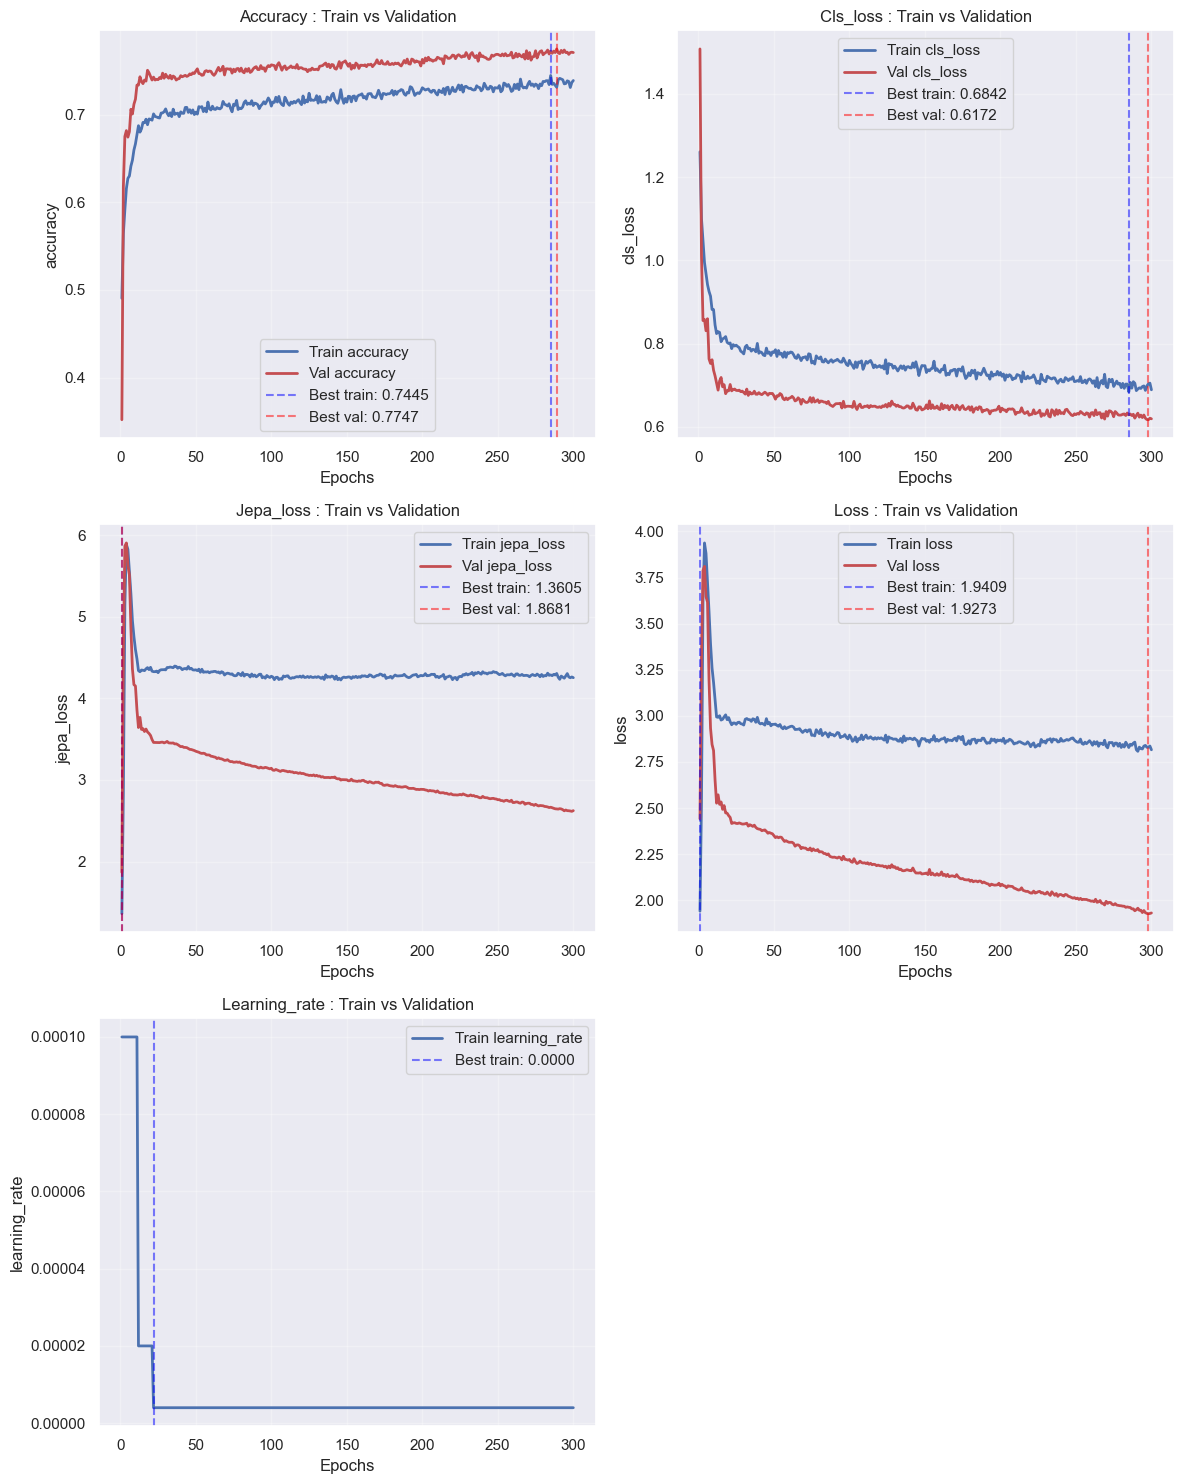

Historique sauvegardé : training_results\plot_cls_jepa_1_history.json
CSV sauvegardé : training_results\plot_cls_jepa_1_history.csv


In [22]:
outils.plot_result(historique,name_fig="plot_cls_jepa_1",register_plot=False)

In [64]:
model_jepa = load_model(filepath="model_jepa_cls_3.keras")

In [73]:

from sklearn.metrics import confusion_matrix,classification_report,f1_score
import seaborn as sns



def evaluation(model, X_test, y_test, return_conf_mat=True, return_clss=True, labels=[]):
    # Prédictions
    y_result, _ = model((X_test, None), training=False)
    y_probs = tf.nn.softmax(y_result, axis=-1)
    y_pred = tf.argmax(y_probs, axis=-1)

    # Matrice de confusion
    conf_matrice = confusion_matrix(y_test, y_pred)

    if return_conf_mat:
        print("========================================== Confusion Matrix =====================================================")
        print(conf_matrice)
        f, ax = plt.subplots(figsize=(6, 5))
        conf_matrice_nor = conf_matrice.astype('float') / conf_matrice.sum(axis=1)[:, np.newaxis]
        sns.heatmap(conf_matrice_nor, annot=True, fmt=".2%", linewidths=.5, ax=ax,
                    xticklabels=labels, yticklabels=labels, cbar=False)
        plt.ylabel("True class")
        plt.xlabel("Predicted class")
        plt.title("Normalized Confusion Matrix")
        plt.show()

    if return_clss:
        print("========================================= Detailed Metrics =====================================================")
        # Rapport complet (inclut précision, rappel et f1-score par classe)
        report = classification_report(y_test, y_pred, target_names=labels, digits=4)
        print(report)

        # F1 macro et weighted
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        print(f"Macro F1-score (unweighted): {f1_macro:.4f}")
        print(f"Weighted F1-score: {f1_weighted:.4f}")
    return y_pred

In [60]:
X_test = X_test.astype('float32') / 255.0

In [70]:
X_test.max(), X_test.min(), X_test.shape

(np.float32(1.0), np.float32(0.0), (2428, 64, 64, 3))

In [68]:
y_result, _ = model_jepa((X_test[0:20], None), training=False)

In [71]:
y_probs = tf.nn.softmax(y_result, axis=-1)
y_pred = tf.argmax(y_probs, axis=-1)

In [72]:
y_pred

<tf.Tensor: shape=(20,), dtype=int64, numpy=array([0, 4, 2, 0, 0, 3, 0, 4, 2, 0, 1, 4, 3, 3, 3, 2, 1, 4, 4, 0])>

In [76]:
evaluation(model=model_jepa, X_test=X_test, y_test=y_test, return_conf_mat=True, return_clss=True, labels=df.name_label_)

ResourceExhaustedError: Exception encountered when calling BatchNormalization.call().

[1m{{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[2428,64,64,64] and type float on /job:localhost/replica:0/task:0/device:CPU:0 by allocator mklcpu [Op:AddV2] name: [0m

Arguments received by BatchNormalization.call():
  • inputs=tf.Tensor(shape=(2428, 64, 64, 64), dtype=float32)
  • training=False
  • mask=None

In [55]:
y_result[0].shape

(2428, 5)

In [23]:
X_test.shape

(2428, 64, 64, 3)

In [29]:
df_an = outils.Load_data.load_object("detect_anomalie.zip")

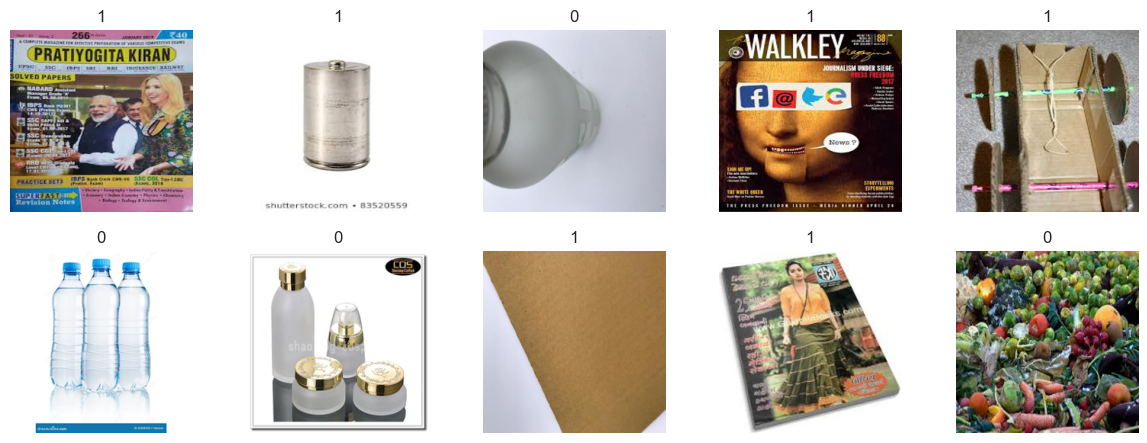

In [43]:
df_an.plot(view_code=True)

In [33]:
df_an.encodage()

In [46]:
df_an.reshape(target_shape=(64, 64, 3))

Reshape en batch: 100%|██████████| 125/125 [00:07<00:00, 16.27it/s]


In [47]:
(X_train_an, y_train_an), (_ , _) = df_an.create_data(test_size=0.00000000000001)

In [48]:
X_train_an.shape

(3999, 64, 64, 3)

In [ ]:
def compute_jepa_score(encoder, image):
    if len(image.shape) == 3:
        image = np.expand_dims(image, axis=0)
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(image)
        latent = encoder(image, training=False)
    
    # Jacobien
    jacobian = tape.jacobian(latent, image)
    
    # Reshape: (latent_dim, -1)
    jacobian = tf.reshape(jacobian, (latent.shape[-1], -1))
    
    # SVD et calcul du score
    s = tf.linalg.svd(jacobian, compute_uv=False)
    score = tf.reduce_sum(tf.math.log(s + 1e-6))
    
    return score.numpy()


In [64]:
from tqdm import tqdm
def compute_scores_batch(encoder, images, batch_size=32):
    scores = []
    n_images = len(images)
    
    for i in tqdm(range(0, n_images, batch_size), desc="Calcul des scores"):
        batch = images[i:min(i+batch_size, n_images)]
        for img in batch:
            score = compute_jepa_score(encoder, img)
            scores.append(score)
    
    return np.array(scores)

In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import seaborn as sns

In [55]:
def find_optimal_threshold(scores_normal, scores_anomaly, metric='f1'):

    all_scores = np.concatenate([scores_normal, scores_anomaly])
    all_labels = np.concatenate([np.zeros(len(scores_normal)), np.ones(len(scores_anomaly))])
    
    # Trier par score
    sorted_indices = np.argsort(all_scores)
    sorted_scores = all_scores[sorted_indices]
    sorted_labels = all_labels[sorted_indices]
    
    best_threshold = None
    best_metric = -1
    
    # Tester différents seuils
    thresholds = np.unique(sorted_scores)
    
    for threshold in thresholds:
        # Prédictions: anomalie si score < threshold
        preds = (all_scores < threshold).astype(int)
        
        if metric == 'f1':
            current_metric = f1_score(all_labels, preds)
        elif metric == 'accuracy':
            current_metric = accuracy_score(all_labels, preds)
        elif metric == 'youden':
            tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            current_metric = sensitivity + specificity - 1
        
        if current_metric > best_metric:
            best_metric = current_metric
            best_threshold = threshold
    
    return best_threshold, best_metric

In [60]:
def evaluate_anomaly_detection(encoder, normal_images, anomaly_images, threshold=None):
    
    print("\n" + "="*60)
    print("ÉVALUATION DE LA DÉTECTION D'ANOMALIES")
    print("="*60)
    
    # Calcul des scores
    print("\n[1] Calcul des scores JEPA...")
    scores_normal = compute_scores_batch(encoder, normal_images)
    scores_anomaly = compute_scores_batch(encoder, anomaly_images)
    
    # Statistiques des scores
    print(f"\nScores normaux: min={scores_normal.min():.4f}, max={scores_normal.max():.4f}, "
          f"mean={scores_normal.mean():.4f}, std={scores_normal.std():.4f}")
    print(f"Scores anomalies: min={scores_anomaly.min():.4f}, max={scores_anomaly.max():.4f}, "
          f"mean={scores_anomaly.mean():.4f}, std={scores_anomaly.std():.4f}")
    
    # Détermination du seuil
    print("\n[2] Détermination du seuil optimal...")
    if threshold is None:
        threshold, best_f1 = find_optimal_threshold(scores_normal, scores_anomaly, metric='f1')
        print(f"Seuil optimal: {threshold:.4f} (F1-score: {best_f1:.4f})")
    else:
        print(f"Seuil utilisé: {threshold:.4f}")
    
    # Prédictions
    all_scores = np.concatenate([scores_normal, scores_anomaly])
    all_labels = np.concatenate([np.zeros(len(scores_normal)), np.ones(len(scores_anomaly))])
    predictions = (all_scores < threshold).astype(int)
    
    # Métriques
    print("\n[3] Métriques de classification...")
    accuracy = accuracy_score(all_labels, predictions)
    precision = precision_score(all_labels, predictions)
    recall = recall_score(all_labels, predictions)
    f1 = f1_score(all_labels, predictions)
    auc_roc = roc_auc_score(all_labels, -all_scores)  # négatif car plus petit = anomalie
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    
    # Rapport détaillé
    print("\n[4] Rapport de classification:")
    print(classification_report(all_labels, predictions, target_names=['Normal', 'Anomalie']))
    
    # Matrice de confusion
    cm = confusion_matrix(all_labels, predictions)
    
    results = {
        'scores_normal': scores_normal,
        'scores_anomaly': scores_anomaly,
        'threshold': threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc,
        'confusion_matrix': cm,
        'predictions': predictions,
        'all_scores': all_scores,
        'all_labels': all_labels
    }
    
    return results

In [56]:
def plot_score_distribution(scores_normal, scores_anomaly, threshold=None, save_path=None):
    """
    Affiche la distribution des scores JEPA pour les images normales et anomalies.
    """
    plt.figure(figsize=(10, 6))
    
    plt.hist(scores_normal, bins=30, alpha=0.7, label='Normal (label 0)', color='blue', density=True)
    plt.hist(scores_anomaly, bins=30, alpha=0.7, label='Anomalie (label 1)', color='red', density=True)
    
    if threshold is not None:
        plt.axvline(x=threshold, color='green', linestyle='--', linewidth=2, 
                   label=f'Seuil = {threshold:.4f}')
    
    plt.xlabel('JEPA-SCORE')
    plt.ylabel('Densité')
    plt.title('Distribution des scores JEPA : Normal vs Anomalie')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure sauvegardée: {save_path}")
    
    plt.show()


def plot_roc_curve(all_labels, all_scores, save_path=None):
    """
    Affiche la courbe ROC.
    """
    fpr, tpr, thresholds = roc_curve(all_labels, -all_scores)  # négatif car plus petit = anomalie
    auc = roc_auc_score(all_labels, -all_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Courbe ROC - Détection d\'anomalies')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure sauvegardée: {save_path}")
    
    plt.show()


def plot_confusion_matrix(confusion_matrix, save_path=None):
    """
    Affiche la matrice de confusion.
    """
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Anomalie'],
                yticklabels=['Normal', 'Anomalie'])
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité terrain')
    plt.title('Matrice de confusion - Détection d\'anomalies')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure sauvegardée: {save_path}")
    
    plt.show()


def plot_score_comparison(results, save_path=None):
    """
    Affiche un graphique en boîte (boxplot) comparant les scores.
    """
    scores_normal = results['scores_normal']
    scores_anomaly = results['scores_anomaly']
    
    plt.figure(figsize=(8, 6))
    
    data = [scores_normal, scores_anomaly]
    bp = plt.boxplot(data, labels=['Normal', 'Anomalie'], patch_artist=True)
    
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    
    plt.ylabel('JEPA-SCORE')
    plt.title('Comparaison des scores JEPA : Normal vs Anomalie')
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure sauvegardée: {save_path}")
    
    plt.show()

In [62]:
def test_anomaly_detection(model_path, test_data_loader, threshold=None, save_dir="anomaly_results"):
    """
    Fonction principale pour tester la détection d'anomalies.
    
    Args:
        model_path: chemin vers le modèle JEPA sauvegardé (.keras)
        test_data_loader: objet Load_data contenant les données de test
        threshold: seuil de détection (optionnel)
        save_dir: répertoire pour sauvegarder les résultats
    
    Returns:
        dict: résultats de l'évaluation
    """
    # Créer le répertoire de sauvegarde
    os.makedirs(save_dir, exist_ok=True)
    
    # ============================================
    # 3.1 Chargement du modèle
    # ============================================
    print("\n" + "="*60)
    print("CHARGEMENT DU MODÈLE JEPA")
    print("="*60)
    
   
    
    model = load_model(model_path)
    encoder = model.encoder  # Récupérer l'encodeur
    
    print(f"Modèle chargé depuis: {model_path}")
    
    # ============================================
    # 3.2 Préparation des données
    # ============================================
    print("\n" + "="*60)
    print("PRÉPARATION DES DONNÉES")
    print("="*60)
    
    # Récupérer les données
    if hasattr(test_data_loader, 'data_') and test_data_loader.data_ is not None:
        df = test_data_loader.data_
    else:
        print("Erreur: Pas de données dans test_data_loader")
        return None
    
    # Séparer normales et anomalies
    normal_images = df[df['Label'] == 0]['Image'].tolist()
    anomaly_images = df[df['Label'] == 1]['Image'].tolist()
    
    print(f"Images normales: {len(normal_images)}")
    print(f"Images anomalies: {len(anomaly_images)}")
    
    # Convertir en arrays numpy
    normal_images = np.array(normal_images)
    anomaly_images = np.array(anomaly_images)
    
    # ============================================
    # 3.3 Évaluation
    # ============================================
    results = evaluate_anomaly_detection(
        encoder=encoder,
        normal_images=normal_images,
        anomaly_images=anomaly_images,
        threshold=threshold
    )
    
    # ============================================
    # 3.4 Visualisation
    # ============================================
    print("\n" + "="*60)
    print("VISUALISATION DES RÉSULTATS")
    print("="*60)
    
    # Distribution des scores
    plot_score_distribution(
        results['scores_normal'],
        results['scores_anomaly'],
        threshold=results['threshold'],
        save_path=os.path.join(save_dir, 'score_distribution.png')
    )
    
    # Courbe ROC
    plot_roc_curve(
        results['all_labels'],
        results['all_scores'],
        save_path=os.path.join(save_dir, 'roc_curve.png')
    )
    
    # Matrice de confusion
    plot_confusion_matrix(
        results['confusion_matrix'],
        save_path=os.path.join(save_dir, 'confusion_matrix.png')
    )
    
    # Boxplot comparatif
    plot_score_comparison(
        results,
        save_path=os.path.join(save_dir, 'boxplot_comparison.png')
    )
    
    # ============================================
    # 3.5 Sauvegarde des résultats
    # ============================================
    print("\n" + "="*60)
    print("SAUVEGARDE DES RÉSULTATS")
    print("="*60)
    
    # Sauvegarde des scores
    scores_df = pd.DataFrame({
        'type': ['normal'] * len(results['scores_normal']) + ['anomaly'] * len(results['scores_anomaly']),
        'score': np.concatenate([results['scores_normal'], results['scores_anomaly']]),
        'true_label': np.concatenate([np.zeros(len(results['scores_normal'])), 
                                       np.ones(len(results['scores_anomaly']))]),
        'predicted_label': results['predictions']
    })
    scores_df.to_csv(os.path.join(save_dir, 'scores.csv'), index=False)
    
    # Sauvegarde des métriques
    metrics_df = pd.DataFrame({
        'metric': ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'threshold'],
        'value': [results['accuracy'], results['precision'], results['recall'],
                  results['f1'], results['auc_roc'], results['threshold']]
    })
    metrics_df.to_csv(os.path.join(save_dir, 'metrics.csv'), index=False)
    
    print(f"Résultats sauvegardés dans: {save_dir}")
    print("Fichiers créés:")
    print("  - score_distribution.png")
    print("  - roc_curve.png")
    print("  - confusion_matrix.png")
    print("  - boxplot_comparison.png")
    print("  - scores.csv")
    print("  - metrics.csv")
    
    return results



CHARGEMENT DU MODÈLE JEPA
Modèle chargé depuis: model_jepa.keras

PRÉPARATION DES DONNÉES
Images normales: 2000
Images anomalies: 2000

ÉVALUATION DE LA DÉTECTION D'ANOMALIES

[1] Calcul des scores JEPA...


Calcul des scores:   0%|          | 0/63 [00:00<?, ?it/s]

Calcul des scores: 100%|██████████| 63/63 [33:07<00:00, 31.55s/it]



Scores normaux: min=-845.7997, max=-549.6995, mean=-711.8890, std=37.5083
Scores anomalies: min=-836.3634, max=-557.0536, mean=-717.3889, std=34.8535

[2] Détermination du seuil optimal...
Seuil optimal: -644.2692 (F1-score: 0.6689)

[3] Métriques de classification...
Accuracy:  0.5125
Precision: 0.5064
Recall:    0.9850
F1-score:  0.6689
AUC-ROC:   0.5410

[4] Rapport de classification:
              precision    recall  f1-score   support

      Normal       0.73      0.04      0.08      2000
    Anomalie       0.51      0.98      0.67      2000

    accuracy                           0.51      4000
   macro avg       0.62      0.51      0.37      4000
weighted avg       0.62      0.51      0.37      4000


VISUALISATION DES RÉSULTATS
Figure sauvegardée: anomaly_test_results\score_distribution.png


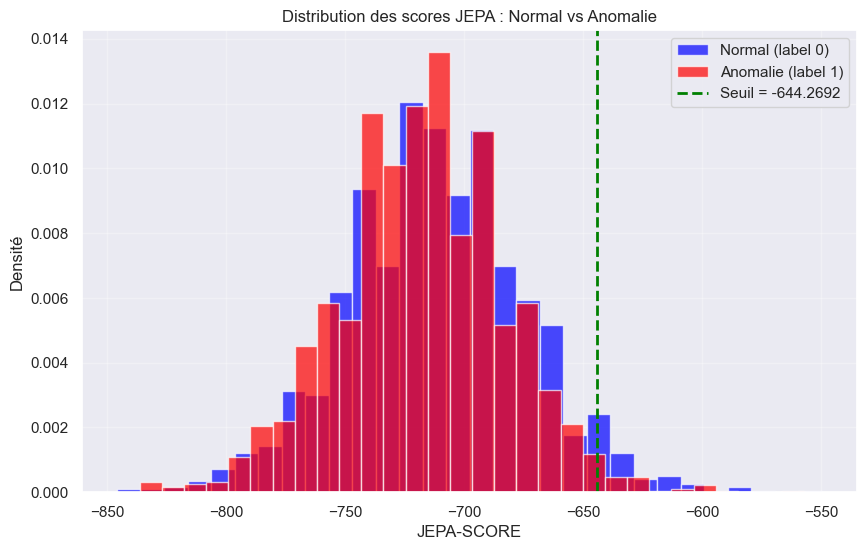

Figure sauvegardée: anomaly_test_results\roc_curve.png


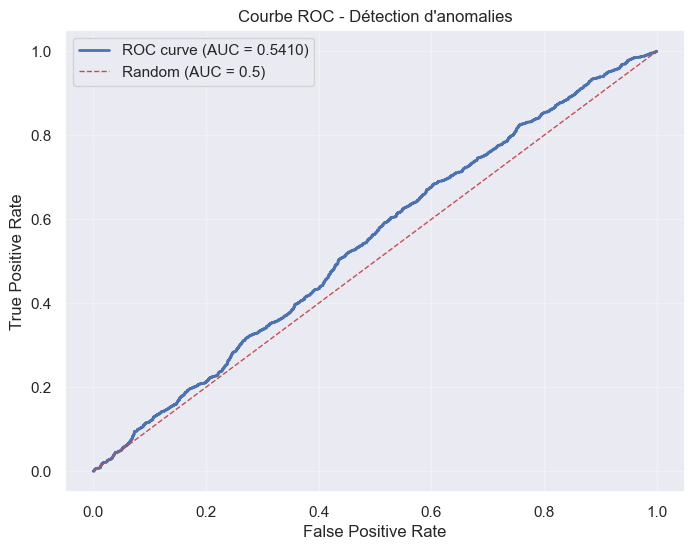

Figure sauvegardée: anomaly_test_results\confusion_matrix.png


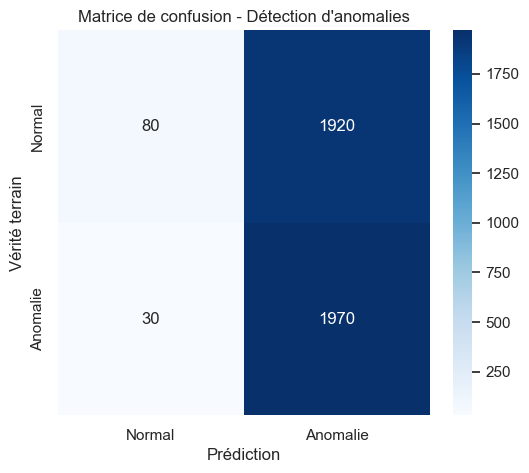

C:\Users\hp\AppData\Local\Temp\ipykernel_11756\2940662695.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=['Normal', 'Anomalie'], patch_artist=True)


Figure sauvegardée: anomaly_test_results\boxplot_comparison.png


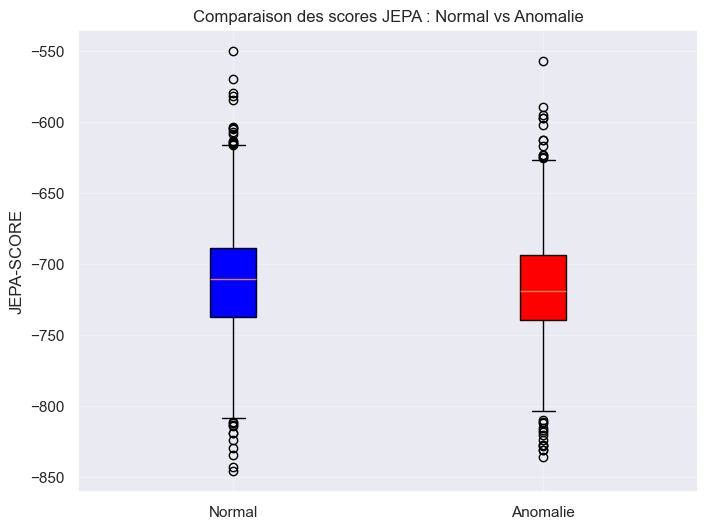


SAUVEGARDE DES RÉSULTATS
Résultats sauvegardés dans: anomaly_test_results
Fichiers créés:
  - score_distribution.png
  - roc_curve.png
  - confusion_matrix.png
  - boxplot_comparison.png
  - scores.csv
  - metrics.csv


In [65]:
results = test_anomaly_detection(
        model_path="model_jepa.keras",  # chemin vers ton modèle
        test_data_loader=df_an,  # ton objet Load_data pour les données de test
        threshold=None,  # seuil automatique
        save_dir="anomaly_test_results"
    )